### 1. Liiketoiminnan ymmärrys

#### Tavoite
- Tutkia miten uni- ja liikuntatottumukset vaikuttavat hyvinvointiin ja aktiivisuustasoon.

#### Keskeiset kysymykset
- Voiko unen määrällä ja tasolla ennustaa tulevien päivien aktiivisuustasoa taikka hyvinvointia?
- Onko eri käyttäjäryhmillä selkeitä eroja unirytmissä ja liikuntamäärissä?
- Mitkä tekijät vaikuttavat unen määrään ja tasoon?

#### Vaadittava data
- Uni (kesto, taso)
- Liikunta (päivittäiset askeleet, aktiivisuusminuutit, kulutetut kalorit)
- Mahdollisesti lisämuuttujat (syke, stressitaso, unihäiriöt)

#### Mahdolliset rajoitteet
- Datan puute (Unen tasot puuttuvat, joten joudumme käyttämään epäsuoria mittareita kuten sykettä, liikunnan vaikutusta uneen, unen kestoa ja sen säännöllisyyttä.
- Käyttäjien erilaiset elämäntyylit ja taustatekijät
- Älykellodatan mahdollinen epätarkkuus

#### Odotetut tulokset
- Käyttäjäryhmien (klusterien) löytäminen unirytmien ja aktiivisuustottumusten perusteella
- Ennustemalli, joka arvioi aktiivisuustason unen perusteella
- Ymmärrys siitä, miten uni vaikuttaa päivittäiseen hyvinvointiin


### 2. Data understanding: The second phase is to collect and explore the data. What data is available? What are the characteristics of the data (variable types, value distributions etc.)? Are there any quality issues with the data (missing values, outliers, nonsensical values)?

#### Tietoa datasetistä

"Tämä aineisto on kerätty vastaajilta hajautetun kyselyn kautta Amazon Mechanical Turkin avulla ajanjaksolla 03.12.2016–05.12.2016. Kolmekymmentä kelpoisuusehdot täyttävää Fitbit-käyttäjää antoi suostumuksensa henkilökohtaisten aktiivisuusmittaridatojen lähettämiseen, mukaan lukien minuuttitasoiset tiedot fyysisestä aktiivisuudesta, sykkeestä ja unen seurannasta. Eri laitteiden ja käyttäjien yksilölliset seurantatavat ja mieltymykset aiheuttavat vaihtelua aineiston tuloksissa."


Lähde: https://www.kaggle.com/datasets/nurudeenabdulsalaam/fitbit-fitness-tracker-data/data

#### Yleiset muuttujat
1. Id: Käyttäjän yksilöivä tunniste
2. TotalSteps: Päivän aikana otetut askeleet
3. TotalDistance: Kuljettu matka kilometreissä
4. Calories: Arvio kulutetuista kaloreista
5. Sleep.Value: 1 = Sleep / 2 = restless / 3 = Awake

In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

daily_activity = pd.read_csv('archive/dailyActivity_merged.csv')
sleep_data = pd.read_csv('archive/sleepDay_merged.csv')
weight_data = pd.read_csv('archive/weightLogInfo_merged.csv')
heartrate_data = pd.read_csv('archive/heartrate_seconds_merged.csv')

# Display the first few rows of each DataFrame to understand the structure
daily_activity.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [228]:

# Check for missing dates in sleep data
print(sleep_data['SleepDay'].isnull().sum())

# Check for missing dates in heartrate data
print(heartrate_data['Time'].isnull().sum())


0
0


In [229]:
sleep_data.head()



,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442
3,1503960366,4/16/2016 12:00:00 AM,2,340,367
4,1503960366,4/17/2016 12:00:00 AM,1,700,712


In [230]:

weight_data.head()

,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,5/2/2016 11:59:59 PM,52.599998,115.963147,22.0,22.650000,True,1462233599000
1,1503960366,5/3/2016 11:59:59 PM,52.599998,115.963147,NaN,22.650000,True,1462319999000
2,1927972279,4/13/2016 1:08:52 AM,133.500000,294.317120,NaN,47.540001,False,1460509732000
3,2873212765,4/21/2016 11:59:59 PM,56.700001,125.002104,NaN,21.450001,True,1461283199000
4,2873212765,5/12/2016 11:59:59 PM,57.299999,126.324875,NaN,21.690001,True,1463097599000


In [231]:
# Check if there are missing values in the merge columns
print("Rows with missing values in 'SleepDay':")
print(sleep_data[sleep_data['SleepDay'].isna()])

print("\nRows with missing values in 'Time':")
print(heartrate_data[heartrate_data['Time'].isna()])


Rows with missing values in 'SleepDay':
Empty DataFrame
Columns: [Id, SleepDay, TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed]
Index: []

Rows with missing values in 'Time':
Empty DataFrame
Columns: [Id, Time, Value]
Index: []


In [232]:

# Step 1: Ensure 'SleepDay' and 'Time' columns are converted to datetime
sleep_data['SleepDay'] = pd.to_datetime(sleep_data['SleepDay'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
heartrate_data['Time'] = pd.to_datetime(heartrate_data['Time'], errors='coerce')

# Step 2: Drop rows with NaT values in the key columns
sleep_data = sleep_data.dropna(subset=['SleepDay'])
heartrate_data = heartrate_data.dropna(subset=['Time'])

# Step 3: Ensure both dataframes are sorted by the 'Id' and the respective datetime columns
sleep_data_sorted = sleep_data.sort_values(by=['Id', 'SleepDay'], ascending=[True, True])
heartrate_data_sorted = heartrate_data.sort_values(by=['Id', 'Time'], ascending=[True, True])

# Step 4: Double-check that sorting was applied properly (for debugging)
print("Sorted Sleep Data:")
print(sleep_data_sorted[['Id', 'SleepDay']].head())  # Check top rows for correct sorting

print("\nSorted Heart Rate Data:")
print(heartrate_data_sorted[['Id', 'Time']].head())  # Check top rows for correct sorting

# Step 5: Perform the as-of merge with direction='nearest'
try:
    merged_data = pd.merge_asof(sleep_data_sorted, heartrate_data_sorted, 
                                 by='Id', 
                                 left_on='SleepDay', right_on='Time', 
                                 direction='nearest')
    
    # Check the merged data
    print("\nMerged Data:")
    print(merged_data.head())

except ValueError as e:
    print(f"Error during merge: {e}")



Sorted Sleep Data:
           Id   SleepDay
0  1503960366 2016-04-12
1  1503960366 2016-04-13
2  1503960366 2016-04-15
3  1503960366 2016-04-16
4  1503960366 2016-04-17

Sorted Heart Rate Data:
           Id                Time
0  2022484408 2016-04-12 07:21:00
1  2022484408 2016-04-12 07:21:05
2  2022484408 2016-04-12 07:21:10
3  2022484408 2016-04-12 07:21:20
4  2022484408 2016-04-12 07:21:25
Error during merge: left keys must be sorted


In [233]:

# Check correlation between heart rate and sleep metrics
correlation_sleep_metrics = merged_data[['Value', 'TotalMinutesAsleep', 'TotalTimeInBed']].corr()
print(correlation_sleep_metrics)

                    Value  TotalMinutesAsleep  TotalTimeInBed
Value                 NaN                 NaN             NaN
TotalMinutesAsleep    NaN            1.000000        0.930457
TotalTimeInBed        NaN            0.930457        1.000000


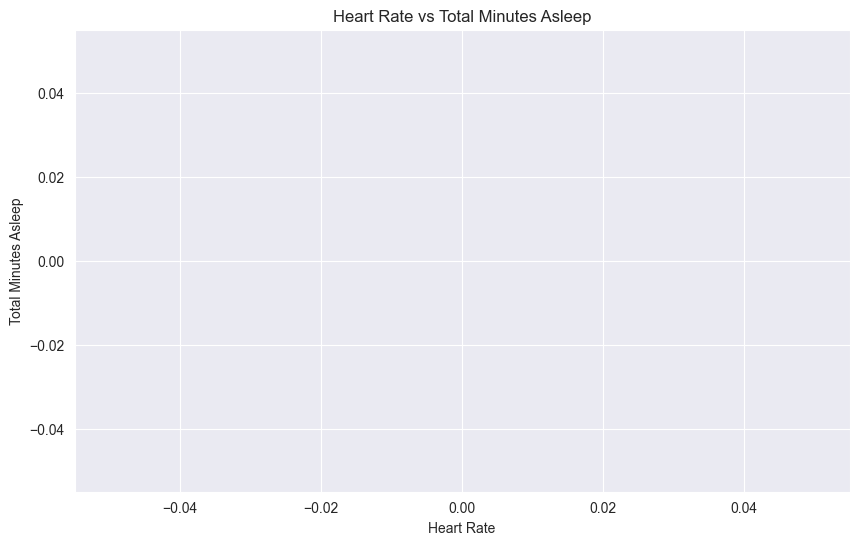

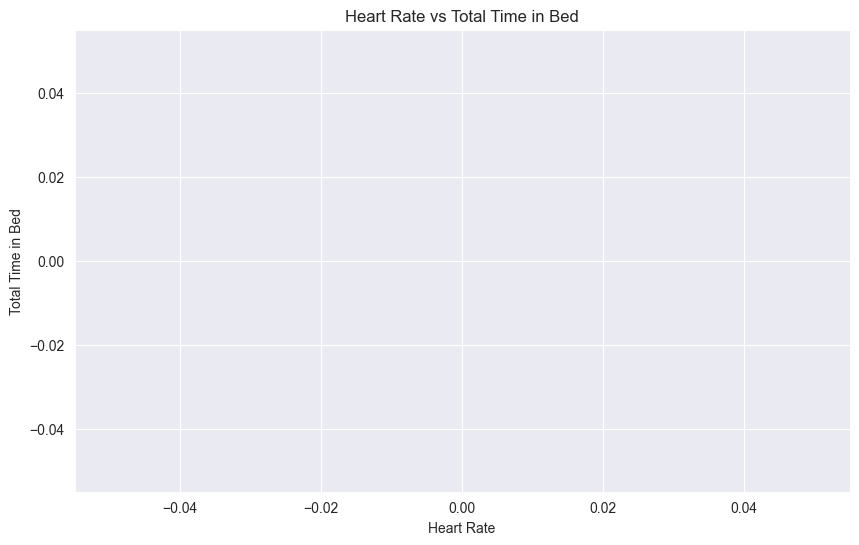

In [234]:

# Scatter plot between heart rate and TotalMinutesAsleep
plt.figure(figsize=(10, 6))
sns.scatterplot(x=merged_data['Value'], y=merged_data['TotalMinutesAsleep'])
plt.title('Heart Rate vs Total Minutes Asleep')
plt.xlabel('Heart Rate')
plt.ylabel('Total Minutes Asleep')
plt.show()

# Scatter plot between heart rate and TotalTimeInBed
plt.figure(figsize=(10, 6))
sns.scatterplot(x=merged_data['Value'], y=merged_data['TotalTimeInBed'])
plt.title('Heart Rate vs Total Time in Bed')
plt.xlabel('Heart Rate')
plt.ylabel('Total Time in Bed')
plt.show()

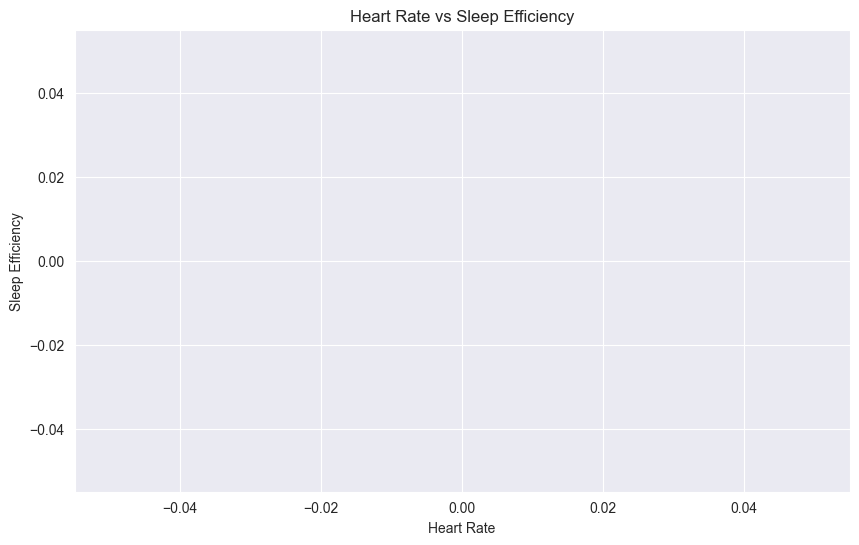

In [235]:

# Create a simple sleep quality indicator (sleep efficiency)
merged_data['SleepEfficiency'] = merged_data['TotalMinutesAsleep'] / merged_data['TotalTimeInBed']

# Plot Sleep Efficiency against Heart Rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x=merged_data['Value'], y=merged_data['SleepEfficiency'])
plt.title('Heart Rate vs Sleep Efficiency')
plt.xlabel('Heart Rate')
plt.ylabel('Sleep Efficiency')
plt.show()

In [236]:

from scipy.stats import pearsonr

# Pearson correlation test between Heart Rate and TotalMinutesAsleep
corr_value, p_value = pearsonr(merged_data['Value'], merged_data['TotalMinutesAsleep'])
print(f"Pearson correlation: {corr_value}, p-value: {p_value}")

# Pearson correlation test between Heart Rate and Sleep Efficiency
corr_efficiency, p_value_efficiency = pearsonr(merged_data['Value'], merged_data['SleepEfficiency'])
print(f"Pearson correlation with Sleep Efficiency: {corr_efficiency}, p-value: {p_value_efficiency}")

Pearson correlation: nan, p-value: nan
Pearson correlation with Sleep Efficiency: nan, p-value: nan


### 3. Data preparation: The third phase is to preprocess the data. This includes cleaning the data, transforming the data, and selecting the relevant features. These steps should be documented in such detail that they can be reproduced later.

### 4. Modeling: The fourth phase is to choose a machine learning method and train the model. This phase also includes the validation of the model. Documentation needs include: which method was used, which parameters were used, what was the performance of the model?

### 5. Evaluation: The fifth phase is to evaluate the model. How well does the model perform? Does it meet the business requirements?

### 6. Deployment: The final phase is to deploy the model. How will the model be used in practice? How will the results be communicated? This phase may involve creating a recommendation of how to use the model in practice, or what to do next.